## Import libraries

In [1]:
import SimpleITK as sitk # type: ignore
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import shutil # type: ignore
import seaborn as sns # type: ignore
from skimage.metrics import peak_signal_noise_ratio as psnr # type: ignore
from skimage.metrics import structural_similarity as ssim # type: ignore
from sklearn.preprocessing import MinMaxScaler # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.preprocessing import MaxAbsScaler # type: ignore
from sklearn.preprocessing import RobustScaler # type: ignore

## Load Datasets

In [2]:
df_adc = pd.read_csv("../Part2/df_adc.csv").set_index("Study Instance UID")
df_hbv = pd.read_csv("../Part2/df_hbv.csv").set_index("Study Instance_UID")
df_t2w = pd.read_csv("../Part2/df_t2w.csv").set_index("Study Instance UID")

## Edge detection

### Sobel Edge detection

In [27]:
def sobel_edge(df):
    image = sitk.ReadImage(df["path"].iloc[4])
    sobel_filter = sitk.SobelEdgeDetectionImageFilter()
    edged_image = sobel_filter.Execute(image)
    edged_image_arr = sitk.GetArrayFromImage(edged_image)

    plt.figure(figsize=(5, 5))
    plt.imshow(edged_image_arr[10], cmap="gray")
    plt.title(f"sobel Edge detection")
    plt.tight_layout()
    plt.show()

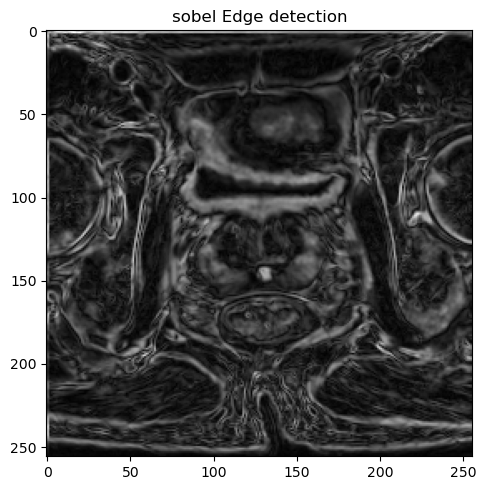

In [28]:
sobel_edge(df_t2w)

### Canny Edge detection

In [82]:
def canny_edge(df):
    image = sitk.ReadImage(df["path"].iloc[5])
    canny_filter = sitk.CannyEdgeDetectionImageFilter()
    canny_filter.SetLowerThreshold(0.0)
    canny_filter.SetUpperThreshold(0.78)
    # canny_filter.SetVariance(1.0)
    edged_image = canny_filter.Execute(image)
    edged_image_arr = sitk.GetArrayFromImage(edged_image)

    plt.figure(figsize=(5, 5))
    plt.imshow(edged_image_arr[10], cmap="gray")
    plt.title(f"canny Edge detection")
    plt.tight_layout()
    plt.show()

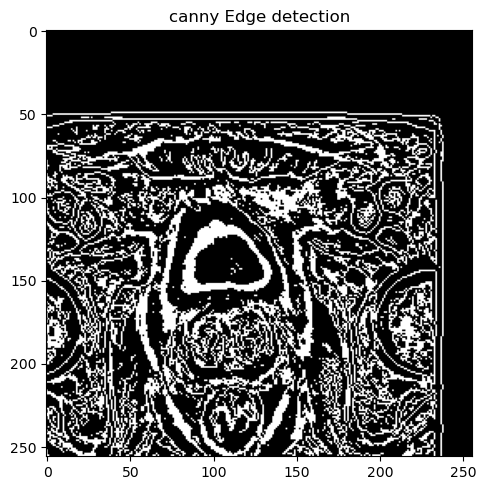

In [83]:
canny_edge(df_t2w)

In [73]:
image = sitk.ReadImage(df_t2w["path"].iloc[5])
gradient_magnitude = sitk.GradientMagnitude(image)
grad_np = sitk.GetArrayFromImage(gradient_magnitude)
values = grad_np.flatten()

lower = np.percentile(values, 10)
upper = np.percentile(values, 90)

print(f"Suggested thresholds: lower={lower:.2f}, upper={upper:.2f}")

Suggested thresholds: lower=0.00, upper=0.78
